# PeakForge Colab Quickstart

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cheneyyu/PeakForge/blob/main/colab/PeakForge_Colab_Quickstart.ipynb)

This notebook shows a transparent Colab workflow for public ENCODE MYC ChIP-seq data.

Workflow in this notebook:

- install `PeakForge`, `samtools`, and `macs3`
- download six public MYC ChIP-seq BAMs plus two matched input-control BAMs
- run an input-aware external `rep3` `1v1` comparison first
- run the matched input-aware `2v2` comparison as the reference truth set
- optionally run a degraded overlapping input-aware `1v1`
- evaluate both `1v1` settings against the `2v2` reference with overlap-based ROC analysis

For Colab, this notebook intentionally ignores `macs2` and installs `macs3` directly with `pip`.
The no-input sensitivity analysis used in the manuscript is not part of this default notebook.


In [1]:
%%time
import os

if not os.path.isdir("PeakForge"):
    !git clone https://github.com/cheneyyu/PeakForge.git

%cd PeakForge


Cloning into 'PeakForge'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 37 (delta 4), reused 22 (delta 4), pack-reused 14 (from 2)
Receiving objects: 100% (37/37), 59.98 KiB | 6.00 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/PeakForge
CPU times: user 7.14 ms, sys: 2.13 ms, total: 9.27 ms
Wall time: 711 ms


In [2]:
%%time
# This install step usually takes about 3-8 min on Colab.
!apt-get update -y
!apt-get install -y samtools
!python3 -m pip install --prefer-binary -e '.[macs3]'


Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,264 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,623 kB]
Hit:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:14 htt

In [3]:
%%time
!peakforge --help
!samtools --version | head -n 1
!macs3 --version


usage: peakforge [-h] {tsvmode,runmode,peakshape,makesheet} ...

CUT&Tag / ChIP-seq differential analysis pipeline

positional arguments:
  {tsvmode,runmode,peakshape,makesheet}
    tsvmode             Run the pipeline using a metadata TSV/CSV sheet
    runmode             Run the pipeline by specifying BAM/peak files directly
    peakshape           Run peak shape profiling for two bigWig tracks
    makesheet           Generate a metadata TSV/CSV from runmode-style
                        arguments

options:
  -h, --help            show this help message and exit
samtools 1.13
macs3 3.0.4
CPU times: user 32.5 ms, sys: 7.39 ms, total: 39.9 ms
Wall time: 13.1 s


If the editable install ever fails because of a future Colab packaging change, retry with explicit package tool upgrades:

```bash
!python3 -m pip install --upgrade pip setuptools wheel
!python3 -m pip install --prefer-binary -e '.[macs3]'
```


## Download Public ENCODE MYC ChIP-seq BAMs And Matched Input Controls

The next cell downloads eight BAMs from ENCODE:

- MYC ChIP-seq: `K562_rep1`, `K562_rep2`, `K562_rep3`, `HepG2_rep1`, `HepG2_rep2`, `HepG2_rep3`
- matched input controls: `K562_input`, `HepG2_input`

The example runs below use the matched K562 and HepG2 input BAMs during peak calling, which is the standard ChIP-seq path.


In [4]:
%%time
import subprocess
from pathlib import Path

THREADS = 2
downloads = [
    (
        "K562_rep1",
        "https://www.encodeproject.org/files/ENCFF975ETI/@@download/ENCFF975ETI.bam",
        Path("example/data/K562_rep1.bam"),
    ),
    (
        "K562_rep2",
        "https://www.encodeproject.org/files/ENCFF380OWL/@@download/ENCFF380OWL.bam",
        Path("example/data/K562_rep2.bam"),
    ),
    (
        "HepG2_rep1",
        "https://www.encodeproject.org/files/ENCFF315AUW/@@download/ENCFF315AUW.bam",
        Path("example/data/HepG2_rep1.bam"),
    ),
    (
        "HepG2_rep2",
        "https://www.encodeproject.org/files/ENCFF987GJQ/@@download/ENCFF987GJQ.bam",
        Path("example/data/HepG2_rep2.bam"),
    ),
    (
        "K562_input",
        "https://www.encodeproject.org/files/ENCFF500EAO/@@download/ENCFF500EAO.bam",
        Path("example/data/K562_input.bam"),
    ),
    (
        "HepG2_input",
        "https://www.encodeproject.org/files/ENCFF062SCH/@@download/ENCFF062SCH.bam",
        Path("example/data/HepG2_input.bam"),
    ),
    (
        "K562_rep3",
        "https://www.encodeproject.org/files/ENCFF953SVM/@@download/ENCFF953SVM.bam",
        Path("example/data2/ENCFF953SVM.bam"),
    ),
    (
        "HepG2_rep3",
        "https://www.encodeproject.org/files/ENCFF439SHL/@@download/ENCFF439SHL.bam",
        Path("example/data2/ENCFF439SHL.bam"),
    ),
]


def run_cmd(cmd):
    cmd = [str(part) for part in cmd]
    print("+", " ".join(cmd))
    subprocess.run(cmd, check=True)


for sample, url, dest in downloads:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists():
        run_cmd(["curl", "-L", "-o", dest, url])
    else:
        print(f"[reuse] {dest}")

    bai_candidates = [Path(f"{dest}.bai"), dest.with_suffix(".bai")]
    if any(path.exists() for path in bai_candidates):
        print(f"[reuse] index for {dest}")
    else:
        run_cmd(["samtools", "index", "-@", str(THREADS), dest])


+ curl -L -o example/data/K562_rep1.bam https://www.encodeproject.org/files/ENCFF975ETI/@@download/ENCFF975ETI.bam
+ samtools index -@ 2 example/data/K562_rep1.bam
+ curl -L -o example/data/K562_rep2.bam https://www.encodeproject.org/files/ENCFF380OWL/@@download/ENCFF380OWL.bam
+ samtools index -@ 2 example/data/K562_rep2.bam
+ curl -L -o example/data/HepG2_rep1.bam https://www.encodeproject.org/files/ENCFF315AUW/@@download/ENCFF315AUW.bam
+ samtools index -@ 2 example/data/HepG2_rep1.bam
+ curl -L -o example/data/HepG2_rep2.bam https://www.encodeproject.org/files/ENCFF987GJQ/@@download/ENCFF987GJQ.bam
+ samtools index -@ 2 example/data/HepG2_rep2.bam
+ curl -L -o example/data/K562_input.bam https://www.encodeproject.org/files/ENCFF500EAO/@@download/ENCFF500EAO.bam
+ samtools index -@ 2 example/data/K562_input.bam
+ curl -L -o example/data/HepG2_input.bam https://www.encodeproject.org/files/ENCFF062SCH/@@download/ENCFF062SCH.bam
+ samtools index -@ 2 example/data/HepG2_input.bam
+ curl

## Direct PeakForge Run 1: External `rep3` `1v1` With Matched Inputs

This first run is the clean external-style `1v1` comparison using the third replicate pair.

It is still input-aware: the K562 and HepG2 common-input BAMs are passed through `--a-controls` and `--b-controls` during peak calling.


In [5]:
%%time
!mkdir -p /content/PeakForge/example/results_colab
!peakforge runmode \
  --condition-a K562 \
  --a-bams /content/PeakForge/example/data2/ENCFF953SVM.bam \
  --a-controls /content/PeakForge/example/data/K562_input.bam \
  --condition-b HepG2 \
  --b-bams /content/PeakForge/example/data2/ENCFF439SHL.bam \
  --b-controls /content/PeakForge/example/data/HepG2_input.bam \
  --output-dir /content/PeakForge/example/results_colab/rep3_1v1 \
  --peak-dir /content/PeakForge/example/results_colab/rep3_1v1/peaks \
  --peak-type narrow \
  --peak-extension 250 \
  --min-overlap 1 \
  --macs2-genome hs \
  --threads 2


[2026-04-18 19:08:06,272] INFO: Detected single-end BAM for /content/PeakForge/example/data2/ENCFF953SVM.bam
[2026-04-18 19:08:08,596] INFO: Detected single-end BAM for /content/PeakForge/example/data2/ENCFF439SHL.bam
[2026-04-18 19:08:08,596] INFO: Estimating library size for sample ENCFF953SVM
[2026-04-18 19:08:08,626] INFO: Estimating library size for sample ENCFF439SHL
[2026-04-18 19:08:08,654] INFO: Launching MACS2 for sample ENCFF953SVM (type=narrow)
[2026-04-18 19:08:08,655] INFO: Launching MACS2 for sample ENCFF439SHL (type=narrow)
INFO  @ 18 Apr 2026 19:08:08: [298 MB] 
# Command line: callpeak -t /content/PeakForge/example/data2/ENCFF439SHL.bam -n /content/PeakForge/example/results_colab/rep3_1v1/peaks/ENCFF439SHL -g hs -q 0.01 -c /content/PeakForge/example/data/HepG2_input.bam
# ARGUMENTS LIST:
# name = /content/PeakForge/example/results_colab/rep3_1v1/peaks/ENCFF439SHL
# format = AUTO
# ChIP-seq file = ['/content/PeakForge/example/data2/ENCFF439SHL.bam']
# control file = ['

In [6]:
%%time
from pathlib import Path

import pandas as pd


def load_consensus_coords(path):
    rows = []
    with Path(path).open() as handle:
        for line in handle:
            if not line.strip():
                continue
            chrom, start, end, peak, *_ = line.rstrip("\n").split("\t")
            rows.append(
                {
                    "Peak": peak,
                    "Chromosome": chrom,
                    "Start": int(start),
                    "End": int(end),
                }
            )
    return pd.DataFrame(rows)


def quick_summary(label, outdir, top_n=5):
    outdir = Path(outdir)
    diff = pd.read_csv(outdir / "differential_results.tsv", sep="	")
    consensus = load_consensus_coords(outdir / "consensus_peaks.bed")
    consensus_count = len(consensus)
    diff = diff.merge(consensus, on="Peak", how="left")
    for coord_col in ["Start", "End"]:
        if coord_col in diff.columns:
            diff[coord_col] = pd.to_numeric(diff[coord_col], errors="coerce").astype("Int64")

    score_col = "padj" if "padj" in diff.columns else "pvalue"
    sig = diff[diff[score_col].fillna(1.0) <= 0.05].copy()
    sort_cols = [score_col]
    if score_col != "pvalue" and "pvalue" in diff.columns:
        sort_cols.append("pvalue")

    top = diff.sort_values(sort_cols, na_position="last").head(top_n).copy()

    print(f"\n[{label}] consensus peaks: {consensus_count}")
    print(f"[{label}] differential rows: {len(diff)}")
    print(f"[{label}] significant peaks ({score_col} <= 0.05): {len(sig)}")
    print(f"[{label}] top {top_n} peaks:")
    cols = [
        col
        for col in ["Chromosome", "Start", "End", "Peak", "log2FC", "pvalue", "padj"]
        if col in top.columns
    ]
    display(top[cols])
    return diff


rep3_diff = quick_summary("external rep3 1v1", "/content/PeakForge/example/results_colab/rep3_1v1")



[external rep3 1v1] consensus peaks: 17953
[external rep3 1v1] differential rows: 17953
[external rep3 1v1] significant peaks (padj <= 0.05): 8171
[external rep3 1v1] top 5 peaks:


,Chromosome,Start,End,Peak,log2FC,pvalue,padj
13417,chr13,91346738,91350017,consensus_4433,-2.479802,3.566650e-146,6.403206e-142
6465,chr22,21628280,21630478,consensus_11597,-2.704887,2.265235e-100,2.033389e-96
16562,chr22,20116718,20118379,consensus_11566,-2.240851,8.156728e-64,4.881258e-60
5551,chr9,131276238,131278492,consensus_17404,-3.674535,6.455538e-42,2.897407e-38
2548,chr7,44985882,44987217,consensus_15540,-5.909241,5.058734e-40,1.816389e-36


CPU times: user 528 ms, sys: 48.6 ms, total: 576 ms
Wall time: 581 ms


## Direct PeakForge Run 2: Matched `2v2` Reference

This second run uses `rep1 + rep2` for each condition and serves as the reference truth set in the later AUROC evaluation.

As in the manuscript benchmark, the MYC ChIP-seq BAMs are run together with the matched K562 and HepG2 input-control BAMs.


In [7]:
%%time
!peakforge runmode \
  --condition-a K562 \
  --a-bams /content/PeakForge/example/data/K562_rep1.bam /content/PeakForge/example/data/K562_rep2.bam \
  --a-controls /content/PeakForge/example/data/K562_input.bam \
  --condition-b HepG2 \
  --b-bams /content/PeakForge/example/data/HepG2_rep1.bam /content/PeakForge/example/data/HepG2_rep2.bam \
  --b-controls /content/PeakForge/example/data/HepG2_input.bam \
  --output-dir /content/PeakForge/example/results_colab/reference_2v2 \
  --peak-dir /content/PeakForge/example/results_colab/reference_2v2/peaks \
  --peak-type narrow \
  --peak-extension 250 \
  --min-overlap 2 \
  --macs2-genome hs \
  --threads 2


[2026-04-18 19:22:31,713] INFO: Detected single-end BAM for /content/PeakForge/example/data/K562_rep1.bam
[2026-04-18 19:22:34,233] INFO: Detected single-end BAM for /content/PeakForge/example/data/K562_rep2.bam
[2026-04-18 19:22:37,760] INFO: Detected single-end BAM for /content/PeakForge/example/data/HepG2_rep1.bam
[2026-04-18 19:22:41,603] INFO: Detected single-end BAM for /content/PeakForge/example/data/HepG2_rep2.bam
[2026-04-18 19:22:41,603] INFO: Estimating library size for sample K562_rep1
[2026-04-18 19:22:41,631] INFO: Estimating library size for sample K562_rep2
[2026-04-18 19:22:41,671] INFO: Estimating library size for sample HepG2_rep1
[2026-04-18 19:22:41,715] INFO: Estimating library size for sample HepG2_rep2
[2026-04-18 19:22:41,764] INFO: Launching MACS2 for sample K562_rep1 (type=narrow)
[2026-04-18 19:22:41,765] INFO: Launching MACS2 for sample K562_rep2 (type=narrow)
[2026-04-18 19:22:41,767] INFO: Launching MACS2 for sample HepG2_rep1 (type=narrow)
[2026-04-18 19

In [8]:
%%time
truth_diff = quick_summary("matched 2v2 reference", "/content/PeakForge/example/results_colab/reference_2v2")



[matched 2v2 reference] consensus peaks: 11954
[matched 2v2 reference] differential rows: 11954
[matched 2v2 reference] significant peaks (padj <= 0.05): 3383
[matched 2v2 reference] top 5 peaks:


,Chromosome,Start,End,Peak,log2FC,pvalue,padj
3863,chr22,22556743,22559642,consensus_7743,-4.874391,5.839080e-14,2.712922e-10
7584,chr17,81991469,81993429,consensus_5193,6.320738,7.190297e-14,2.712922e-10
7585,chr17,81999384,82001399,consensus_5194,5.791467,9.069636e-14,2.712922e-10
3289,chr2,241770308,241771874,consensus_7096,5.574869,9.077873e-14,2.712922e-10
3672,chr2,42978037,42980440,consensus_6426,4.569670,1.565144e-13,3.741946e-10


CPU times: user 160 ms, sys: 4.87 ms, total: 165 ms
Wall time: 176 ms


## Optional: Degraded Overlapping `1v1`

This optional run uses `rep1` only and is deliberately closer to the `2v2` reference, because it overlaps with one replicate from that reference design.

It uses the same matched input-control BAMs and serves only as an additional comparison against the cleaner external `rep3` `1v1` pair.


In [9]:
%%time
!peakforge runmode \
  --condition-a K562 \
  --a-bams /content/PeakForge/example/data/K562_rep1.bam \
  --a-controls /content/PeakForge/example/data/K562_input.bam \
  --condition-b HepG2 \
  --b-bams /content/PeakForge/example/data/HepG2_rep1.bam \
  --b-controls /content/PeakForge/example/data/HepG2_input.bam \
  --output-dir /content/PeakForge/example/results_colab/overlap_rep1_1v1 \
  --peak-dir /content/PeakForge/example/results_colab/overlap_rep1_1v1/peaks \
  --peak-type narrow \
  --peak-extension 250 \
  --min-overlap 1 \
  --macs2-genome hs \
  --threads 2


[2026-04-18 19:49:28,437] INFO: Detected single-end BAM for /content/PeakForge/example/data/K562_rep1.bam
[2026-04-18 19:49:31,940] INFO: Detected single-end BAM for /content/PeakForge/example/data/HepG2_rep1.bam
[2026-04-18 19:49:31,940] INFO: Estimating library size for sample K562_rep1
[2026-04-18 19:49:31,969] INFO: Estimating library size for sample HepG2_rep1
[2026-04-18 19:49:31,996] INFO: Launching MACS2 for sample K562_rep1 (type=narrow)
[2026-04-18 19:49:31,997] INFO: Launching MACS2 for sample HepG2_rep1 (type=narrow)
INFO  @ 18 Apr 2026 19:49:32: [298 MB] 
# Command line: callpeak -t /content/PeakForge/example/data/HepG2_rep1.bam -n /content/PeakForge/example/results_colab/overlap_rep1_1v1/peaks/HepG2_rep1 -g hs -q 0.01 -c /content/PeakForge/example/data/HepG2_input.bam
# ARGUMENTS LIST:
# name = /content/PeakForge/example/results_colab/overlap_rep1_1v1/peaks/HepG2_rep1
# format = AUTO
# ChIP-seq file = ['/content/PeakForge/example/data/HepG2_rep1.bam']
# control file = ['/

In [10]:
%%time
overlap_diff = quick_summary("overlapping rep1 1v1", "/content/PeakForge/example/results_colab/overlap_rep1_1v1")



[overlapping rep1 1v1] consensus peaks: 19079
[overlapping rep1 1v1] differential rows: 19079
[overlapping rep1 1v1] significant peaks (padj <= 0.05): 9205
[overlapping rep1 1v1] top 5 peaks:


,Chromosome,Start,End,Peak,log2FC,pvalue,padj
19040,chr13,91346766,91350502,consensus_4863,-2.266827,2.648880e-129,5.053799e-125
4992,chr22,21628239,21630466,consensus_12065,-2.519514,1.182189e-85,1.127749e-81
10261,chr22,20116790,20118624,consensus_12034,-2.290936,8.609060e-63,5.475075e-59
5036,chr2,42978037,42980440,consensus_9994,4.794153,4.762739e-55,2.271707e-51
17170,chr17,81991469,81993429,consensus_8207,5.749963,2.108785e-45,8.046702e-42


CPU times: user 132 ms, sys: 5.85 ms, total: 138 ms
Wall time: 139 ms


## Overlap-based AUROC Against the `2v2` Reference

The three analyses above are already sufficient for this benchmark:

- the matched `2v2` reference run
- the external `rep3` `1v1` run
- the overlapping `rep1` `1v1` run

The next cell therefore does not rerun PeakForge. Instead, it reuses the existing consensus BEDs and differential tables and evaluates each `1v1` result by genomic overlap against the `2v2` reference.

Evaluation design:

- each `2v2` consensus peak is treated as a reference interval
- positives are `2v2` peaks with `padj <= 0.05`
- for each `2v2` peak, overlapping `1v1` peaks are identified by coordinates
- the assigned `1v1` score is the maximum overlapping `abs(log2FC)`
- `2v2` peaks without any overlapping `1v1` interval are excluded from the overlap-based AUROC


[2v2 truth] total consensus peaks: 11954
[2v2 truth] significant peaks (padj <= 0.05): 3383
[external rep3 1v1] overlapping 2v2 peaks used for AUROC: 10241
[overlapping rep1 1v1] overlapping 2v2 peaks used for AUROC: 11776


,comparison,overlapping_2v2_peaks,truth_positive_peaks_in_overlap,mean_overlaps_per_2v2_peak,mean_best_overlap_bp,overlap_abs_log2fc_auroc
0,External rep3 1v1 vs 2v2 truth,10241,2770,1.031540,824.481398,0.950361
1,Overlapping rep1 1v1 vs 2v2 truth,11776,3368,1.026155,796.651664,0.971312



[external rep3 1v1] top matched 2v2 peaks by overlap-derived score:


,Chromosome,Start,End,Peak,truth_positive,n_overlaps,best_overlap_bp,best_query_peak,best_abs_log2fc
9852,chr22,22556743,22559642,consensus_7743,True,2,1310,consensus_11616,7.692457
9846,chr22,21754287,21755339,consensus_7735,True,1,796,consensus_11607,7.529196
6902,chr15,58864326,58865390,consensus_3524,True,1,1064,consensus_5269,7.526976
1025,chr1,235650379,235651469,consensus_1208,True,1,1090,consensus_1747,7.371907
7018,chr15,78993761,78994837,consensus_3653,True,1,874,consensus_5457,7.077845



[overlapping rep1 1v1] top matched 2v2 peaks by overlap-derived score:


,Chromosome,Start,End,Peak,truth_positive,n_overlaps,best_overlap_bp,best_query_peak,best_abs_log2fc
7482,chr13,107941901,107942648,consensus_3020,True,1,738,consensus_4907,8.025897
11301,chr22,22556743,22559642,consensus_7743,True,2,1347,consensus_12089,7.982341
9425,chr17,68377907,68379290,consensus_4997,True,1,1190,consensus_7913,7.922082
2048,chr2,240856543,240858181,consensus_7077,True,1,1638,consensus_11070,7.897314
7558,chr14,23638850,23639668,consensus_3097,True,1,791,consensus_5031,7.667617


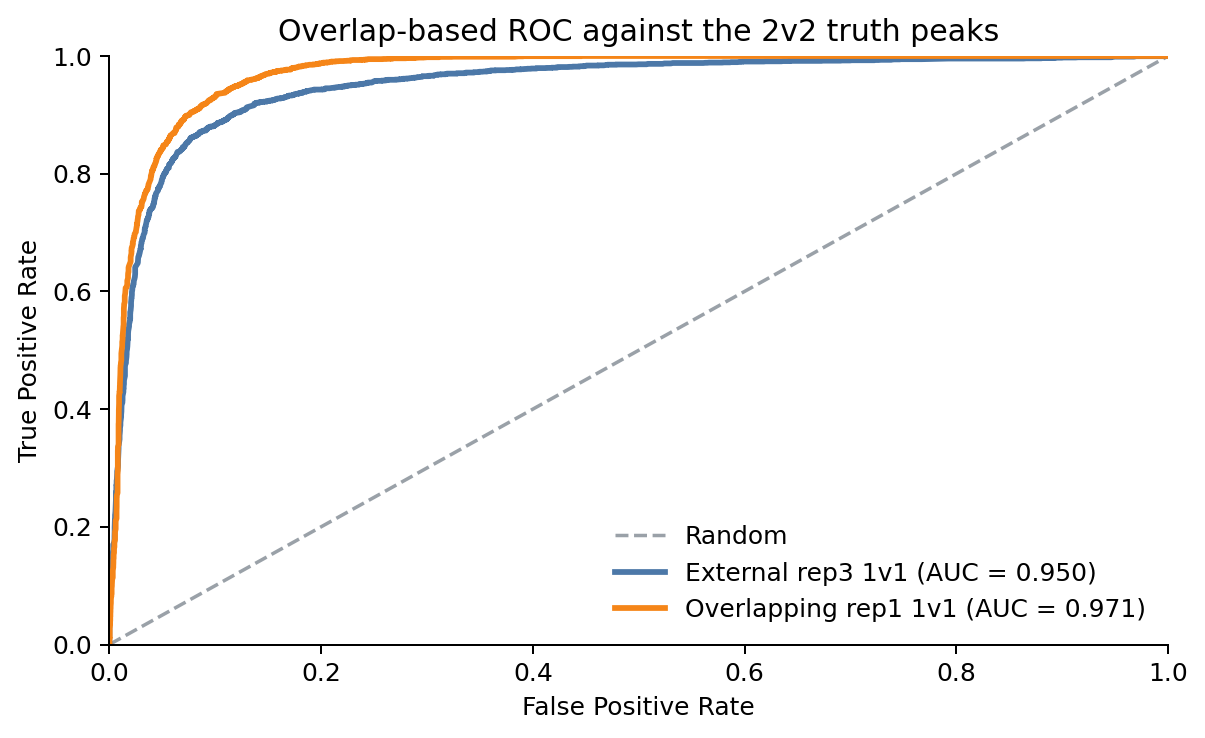

Saved figure to /content/PeakForge/example/results_colab/rep3_vs_overlap_roc_overlap_based.png
CPU times: user 4.95 s, sys: 98.7 ms, total: 5.05 s
Wall time: 4.97 s


In [11]:
%%time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import rankdata

ROOT = Path('/content/PeakForge')
RESULTS = ROOT / 'example' / 'results_colab'


def load_bed(path):
    rows = []
    with Path(path).open() as handle:
        for line in handle:
            if not line.strip():
                continue
            chrom, start, end, name, *_ = line.rstrip('\n').split('\t')
            rows.append((chrom, int(start), int(end), name))
    return rows


def load_result_map(path):
    df = pd.read_csv(path, sep='\t')
    return df, {row['Peak']: row for _, row in df.iterrows()}


def auc_from_scores(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    n_pos = int(y_true.sum())
    n_neg = int((1 - y_true).sum())
    if n_pos == 0 or n_neg == 0:
        return float('nan')
    ranks = rankdata(scores, method='average')
    pos_rank_sum = ranks[y_true == 1].sum()
    return float((pos_rank_sum - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


def build_query_index(query_bed):
    by_chrom = {}
    for chrom, start, end, name in query_bed:
        by_chrom.setdefault(chrom, []).append((start, end, name))
    for chrom in by_chrom:
        by_chrom[chrom].sort()
    return by_chrom


def overlap_score_table(reference_bed, reference_map, query_bed, query_map, alpha=0.05):
    query_index = build_query_index(query_bed)
    rows = []
    labels = []
    scores = []

    for chrom, ref_start, ref_end, ref_peak in reference_bed:
        overlaps = []
        for query_start, query_end, query_peak in query_index.get(chrom, []):
            if query_end <= ref_start:
                continue
            if query_start >= ref_end:
                break
            overlap_bp = min(ref_end, query_end) - max(ref_start, query_start)
            if overlap_bp <= 0:
                continue
            query_lfc = abs(float(query_map[query_peak]['log2FC']))
            overlaps.append((overlap_bp, query_lfc, query_peak))

        if not overlaps:
            continue

        best_overlap_bp, best_score, best_query_peak = max(overlaps, key=lambda item: item[1])
        is_positive = float(reference_map[ref_peak].get('padj', 1.0)) <= alpha
        labels.append(is_positive)
        scores.append(best_score)
        rows.append(
            {
                'Chromosome': chrom,
                'Start': ref_start,
                'End': ref_end,
                'Peak': ref_peak,
                'truth_positive': is_positive,
                'n_overlaps': len(overlaps),
                'best_overlap_bp': best_overlap_bp,
                'best_query_peak': best_query_peak,
                'best_abs_log2fc': best_score,
            }
        )

    table = pd.DataFrame(rows)
    return table, auc_from_scores(labels, scores)


def roc_curve_from_scores(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    positives = int(y_true.sum())
    negatives = int((1 - y_true).sum())
    if positives == 0 or negatives == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0])

    order = np.argsort(-scores, kind='mergesort')
    y_sorted = y_true[order]
    score_sorted = scores[order]

    tpr = [0.0]
    fpr = [0.0]
    tp = 0
    fp = 0
    idx = 0
    while idx < len(score_sorted):
        end = idx + 1
        while end < len(score_sorted) and score_sorted[end] == score_sorted[idx]:
            end += 1
        tp += int(y_sorted[idx:end].sum())
        fp += int((end - idx) - y_sorted[idx:end].sum())
        tpr.append(tp / positives)
        fpr.append(fp / negatives)
        idx = end

    if tpr[-1] != 1.0 or fpr[-1] != 1.0:
        tpr.append(1.0)
        fpr.append(1.0)
    return np.asarray(fpr), np.asarray(tpr)


truth_df, truth_map = load_result_map(RESULTS / 'reference_2v2' / 'differential_results.tsv')
truth_bed = load_bed(RESULTS / 'reference_2v2' / 'consensus_peaks.bed')
print(f"[2v2 truth] total consensus peaks: {len(truth_bed)}")
print(f"[2v2 truth] significant peaks (padj <= 0.05): {(truth_df['padj'].fillna(1.0) <= 0.05).sum()}")

_, rep3_map = load_result_map(RESULTS / 'rep3_1v1' / 'differential_results.tsv')
rep3_bed = load_bed(RESULTS / 'rep3_1v1' / 'consensus_peaks.bed')
_, rep1_map = load_result_map(RESULTS / 'overlap_rep1_1v1' / 'differential_results.tsv')
rep1_bed = load_bed(RESULTS / 'overlap_rep1_1v1' / 'consensus_peaks.bed')

rep3_overlap, rep3_auc = overlap_score_table(truth_bed, truth_map, rep3_bed, rep3_map)
rep1_overlap, rep1_auc = overlap_score_table(truth_bed, truth_map, rep1_bed, rep1_map)

print(f"[external rep3 1v1] overlapping 2v2 peaks used for AUROC: {len(rep3_overlap)}")
print(f"[overlapping rep1 1v1] overlapping 2v2 peaks used for AUROC: {len(rep1_overlap)}")

summary = pd.DataFrame([
    {
        'comparison': 'External rep3 1v1 vs 2v2 truth',
        'overlapping_2v2_peaks': int(len(rep3_overlap)),
        'truth_positive_peaks_in_overlap': int(rep3_overlap['truth_positive'].sum()),
        'mean_overlaps_per_2v2_peak': float(rep3_overlap['n_overlaps'].mean()),
        'mean_best_overlap_bp': float(rep3_overlap['best_overlap_bp'].mean()),
        'overlap_abs_log2fc_auroc': rep3_auc,
    },
    {
        'comparison': 'Overlapping rep1 1v1 vs 2v2 truth',
        'overlapping_2v2_peaks': int(len(rep1_overlap)),
        'truth_positive_peaks_in_overlap': int(rep1_overlap['truth_positive'].sum()),
        'mean_overlaps_per_2v2_peak': float(rep1_overlap['n_overlaps'].mean()),
        'mean_best_overlap_bp': float(rep1_overlap['best_overlap_bp'].mean()),
        'overlap_abs_log2fc_auroc': rep1_auc,
    },
])
display(summary)

print('\n[external rep3 1v1] top matched 2v2 peaks by overlap-derived score:')
display(rep3_overlap.sort_values('best_abs_log2fc', ascending=False).head(5))
print('\n[overlapping rep1 1v1] top matched 2v2 peaks by overlap-derived score:')
display(rep1_overlap.sort_values('best_abs_log2fc', ascending=False).head(5))

rep3_fpr, rep3_tpr = roc_curve_from_scores(rep3_overlap['truth_positive'], rep3_overlap['best_abs_log2fc'])
rep1_fpr, rep1_tpr = roc_curve_from_scores(rep1_overlap['truth_positive'], rep1_overlap['best_abs_log2fc'])

fig, ax = plt.subplots(figsize=(6.8, 4.2), dpi=180)
ax.plot([0, 1], [0, 1], linestyle='--', color='#9AA1A8', linewidth=1.4, label='Random')
ax.plot(rep3_fpr, rep3_tpr, color='#4C78A8', linewidth=2.3, label=f'External rep3 1v1 (AUC = {rep3_auc:.3f})')
ax.plot(rep1_fpr, rep1_tpr, color='#F58518', linewidth=2.3, label=f'Overlapping rep1 1v1 (AUC = {rep1_auc:.3f})')
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Overlap-based ROC against the 2v2 truth peaks')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()

figure_path = RESULTS / 'rep3_vs_overlap_roc_overlap_based.png'
fig.savefig(figure_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'Saved figure to {figure_path}')


## Recommended Colab Pattern

For ordinary Colab use, the simplest paths are still:

1. direct `runmode` on a small number of BAMs
2. reuse pre-called peaks together with BAMs
3. reuse an existing consensus BED

For ChIP-seq, provide matched input BAMs with `--a-controls` and `--b-controls` when you want PeakForge to call peaks.


## Template A: BAMs Plus Pre-called Peaks

Edit the paths and run in a new Colab code cell:

```bash
peakforge runmode \
  --condition-a Tumor \
  --a-bams /content/data/tumor.bam \
  --a-controls /content/data/tumor_input.bam \
  --a-peaks /content/data/tumor_peaks.narrowPeak \
  --condition-b Nearby \
  --b-bams /content/data/nearby.bam \
  --b-controls /content/data/nearby_input.bam \
  --b-peaks /content/data/nearby_peaks.narrowPeak \
  --output-dir /content/results_precalled \
  --peak-type narrow \
  --threads 2
```

For ATAC-seq or CUT&Tag, omit the control arguments.


## Template B: BAMs Plus Existing Consensus Peaks

If you already have a consensus BED from a previous analysis:

```bash
peakforge runmode \
  --condition-a Tumor \
  --a-bams /content/data/tumor.bam \
  --condition-b Nearby \
  --b-bams /content/data/nearby.bam \
  --output-dir /content/results_consensus \
  --consensus-peaks /content/data/consensus_peaks.bed \
  --threads 2
```

If you are also asking PeakForge to call ChIP-seq peaks from BAMs elsewhere in the workflow, keep using matched input BAMs through `--a-controls` and `--b-controls`.


## Optional: Google Drive

If your BAM files live on Google Drive, mount it first in a code cell:

```python
from google.colab import drive
drive.mount('/content/drive')
```

Then replace `/content/data/...` with your Drive paths.
